# Dynamic Pricing Model for Local Events and Experiences.

Includes reinforcement learning and real-time data APIs for a more advanced pricing strategy. 

In [3]:
import pandas as pd
import numpy as np
import requests
import time
import re
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

In [4]:
import tweepy
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager

## Scraping Local Indian Event Data (BookMyShow Stub)
Scrape data of movie title and its genre from bookmyshows website using selenium module

In [5]:
def scrape_bookmyshow_movies(city="chennai"):
    url = f"https://in.bookmyshow.com/explore/home/{city}"
    options = Options()
    options.add_argument('--no-sandbox')
    options.add_argument('--disable-dev-shm-usage')

    driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
    driver.get(url)

    time.sleep(5)  # wait for content

    try:
        WebDriverWait(driver, 10).until(
            EC.presence_of_all_elements_located((By.CLASS_NAME, "sc-7o7nez-0"))
        )
        movie_elements = driver.find_elements(By.CLASS_NAME, "sc-7o7nez-0")
    except Exception as e:
        print("Error while scraping:", e)
        driver.quit()
        return pd.DataFrame()

    events = []
    for i in range(len(movie_elements) - 1):
        title = movie_elements[i].text.strip()
        genre = movie_elements[i+1].text.strip()

        if not title or any(k in title.lower() for k in ["see all", "recommended", "trending", "/"]):
            continue
        if not any(x in genre.lower() for x in ["thriller", "drama", "action", "comedy"]):
            continue

        events.append({"title": title, "genre": genre})

    driver.quit()
    return pd.DataFrame(events)

In [6]:
indian_events = scrape_bookmyshow_movies()
print(indian_events.head())

                     title                         genre
0                  Maargan   Crime/Supernatural/Thriller
1  Jurassic World: Rebirth        Action/Sci-Fi/Thriller
2            F1: The Movie           Action/Drama/Sports
3                      DNA                Crime/Thriller
4                  Kuberaa  Action/Drama/Social/Thriller


## Sentiment Analysis from Twitter-like Posts using twitter API key.

In [7]:
TWITTER_BEARER_TOKEN = "AAAAAAAAAAAAAAAAAAAAAGdz2wEAAAAAJVklP2B4HQgTumg0719684pWAmE%3DEGmo1FaBUzFiv7fcyHCjiZJBChGxh3cq37K5GElvBO3MHKF54M"
client = tweepy.Client(bearer_token=TWITTER_BEARER_TOKEN)

def fetch_tweet_sentiment(title):
    try:
        tweets = client.search_recent_tweets(query=title, max_results=10)
        sentiments = []
        if tweets and tweets.data:
            for tweet in tweets.data:
                blob = TextBlob(tweet.text)
                sentiments.append(blob.sentiment.polarity)
        return np.mean(sentiments) if sentiments else 0
    except:
        return 0

indian_events['sentiment'] = indian_events['title'].apply(fetch_tweet_sentiment)


In [8]:
genre_sentiment_map = {
    'action': 0.1,
    'thriller': 0.2,
    'comedy': 0.3,
    'drama': 0.15,
    'sci-fi': 0.1,
    'crime': -0.1,
    'social': 0.05
}

def genre_based_sentiment(genre):
    sentiment = 0
    genre = genre.lower()
    for key in genre_sentiment_map:
        if key in genre:
            sentiment += genre_sentiment_map[key]
    return sentiment

indian_events['sentiment'] = indian_events.apply(
    lambda row: genre_based_sentiment(row['genre']) if row['sentiment'] == 0 else row['sentiment'],
    axis=1
)


In [9]:
indian_events

,title,genre,sentiment
0,Maargan,Crime/Supernatural/Thriller,0.126786
1,Jurassic World: Rebirth,Action/Sci-Fi/Thriller,0.400000
2,F1: The Movie,Action/Drama/Sports,0.250000
3,DNA,Crime/Thriller,0.100000
4,Kuberaa,Action/Drama/Social/Thriller,0.500000


## Training and predicting data from obtained information, data then validated through metrics performance (RMSE AND R^2)

In [10]:
np.random.seed(42)
data = indian_events.copy()
data = data[data['sentiment'] != 0]
data['competitor_price'] = np.random.uniform(300, 1200, len(data))
data['price'] = (
    100 * data['sentiment'] +
    0.8 * data['competitor_price'] +
    np.random.normal(0, 30, len(data))
)

In [11]:
X = data[['sentiment', 'competitor_price']]
y = data['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
if np.isnan(r2):
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    print("R2 Score: Not defined (NaN) — showing RMSE instead:", rmse)
else:
    print("R2 Score:", r2)

R2 Score: Not defined (NaN) — showing RMSE instead: 71.6819809968191


## Using matplotlib to visualise relevant graphs between sentiment and price

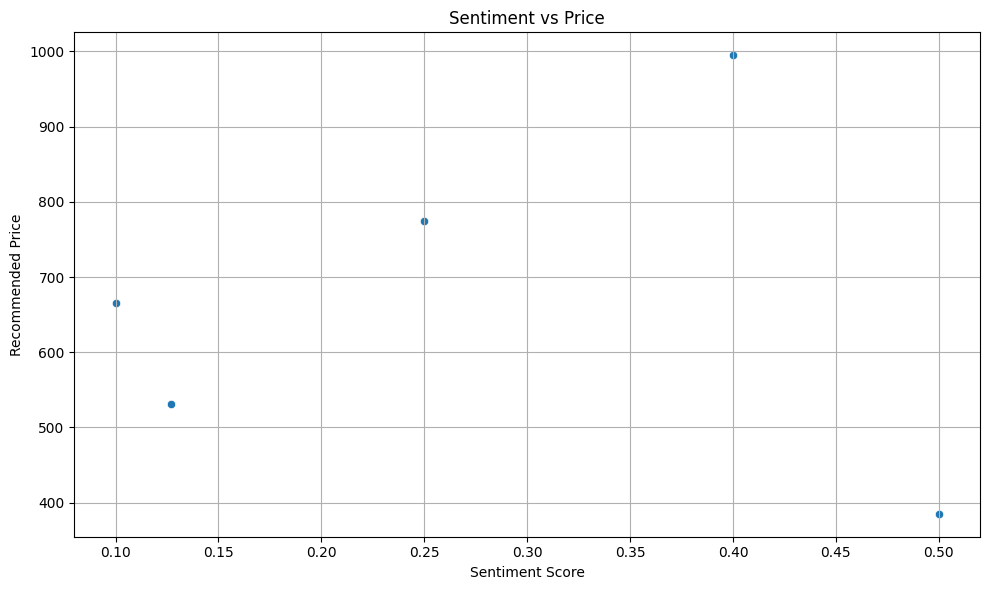

In [12]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='sentiment', y='price', data=data)
plt.title('Sentiment vs Price')
plt.xlabel('Sentiment Score')
plt.ylabel('Recommended Price')
plt.grid(True)
plt.tight_layout()
plt.show()

## Q-Learning Pricing Strategy (Sentiment only) - Reinforcement Learning


In [13]:
price_levels = [500, 800, 1000, 1200, 1500]
q_table = pd.DataFrame(0.0, index=['low', 'medium', 'high'], columns=price_levels)
def get_sentiment_state(score):
    if score < 0.1:
        return 'low'
    elif score < 0.2:
        return 'medium'
    else:
        return 'high'

data['sentiment_state'] = data['sentiment'].apply(get_sentiment_state)

alpha = 0.1
gamma = 0.9

for i, row in data.iterrows():
    sentiment = row['sentiment_state']
    for action in price_levels:
        if sentiment == 'high':
            multiplier = 1.2 if action >= 1000 else 1.0
        elif sentiment == 'medium':
            multiplier = 1.0 if action <= 1000 else 0.9
        else:
            multiplier = 0.8 if action <= 800 else 0.6

        reward = (1 + row['sentiment']) * multiplier
        old_q = q_table.loc[sentiment, action]
        q_table.loc[sentiment, action] = (1 - alpha) * old_q + alpha * (reward + gamma * q_table.loc[sentiment].max())

q_table = q_table / q_table.max().max()
print("\nQ-Table:")
print(q_table)


Q-Table:
            500       800       1000      1200      1500
low     0.000000  0.000000  0.000000  0.000000  0.000000
medium  0.411283  0.444586  0.449101  0.410574  0.410574
high    0.780092  0.823822  0.971210  0.996321  1.000000


The rows here represent sentiment of the time and the columns each are the pricing of the tickets

## Summarising the project

In [14]:
print("\n--- Project Summary ---")
print(f"Total Events Analyzed: {len(indian_events)}")
print(f"Events Used in Pricing Model: {len(data)}")
print("\nModel Insights:")
if np.isnan(r2):
    print(f"Model RMSE: {rmse:.2f} (R2 undefined due to limited variation in test set)")
else:
    print(f"Model R2 Score: {r2:.4f}")
print("\nQ-Table Pricing Strategy (normalized rewards):")
print(q_table)
print("\nUse this table to identify optimal price points based on predicted sentiment category.")
print("For example, if sentiment is 'high', price closer to 1200–1500 may yield better revenue.")


--- Project Summary ---
Total Events Analyzed: 5
Events Used in Pricing Model: 5

Model Insights:
Model RMSE: 71.68 (R2 undefined due to limited variation in test set)

Q-Table Pricing Strategy (normalized rewards):
            500       800       1000      1200      1500
low     0.000000  0.000000  0.000000  0.000000  0.000000
medium  0.411283  0.444586  0.449101  0.410574  0.410574
high    0.780092  0.823822  0.971210  0.996321  1.000000

Use this table to identify optimal price points based on predicted sentiment category.
For example, if sentiment is 'high', price closer to 1200–1500 may yield better revenue.


In [15]:
data.to_csv("event_data.csv", index=False)
q_table.to_csv("q_table.csv")